In [1]:
import os
import sys
os.makedirs("src", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)
sys.path.append("/content")
print("Folders created successfully.")

Folders created successfully.


In [2]:
%%writefile src/data_generator.py
import os
import numpy as np
import pandas as pd


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def generate_supply_chain_data(n_samples=8000, random_state=42):
    np.random.seed(random_state)

    warehouse_regions = ["North", "South", "East", "West"]
    product_categories = ["Electronics", "Apparel", "Home", "Groceries", "Beauty"]
    shipment_priorities = ["Low", "Medium", "High"]

    data = pd.DataFrame({
        "inventory_level": np.random.randint(20, 800, n_samples),
        "demand_forecast": np.random.randint(50, 1000, n_samples),
        "supplier_reliability": np.round(np.random.uniform(0.55, 0.99, n_samples), 2),
        "supplier_lead_time_days": np.random.randint(1, 21, n_samples),
        "warehouse_utilization": np.round(np.random.uniform(0.45, 0.98, n_samples), 2),
        "shipping_distance": np.random.randint(20, 3500, n_samples),
        "weather_severity": np.random.randint(0, 11, n_samples),
        "carrier_delay_history": np.round(np.random.uniform(0.01, 0.45, n_samples), 2),
        "carrier_reliability": np.round(np.random.uniform(0.55, 0.99, n_samples), 2),
        "processing_time_hours": np.round(np.random.uniform(2, 96, n_samples), 1),
        "promised_delivery_days": np.random.randint(1, 11, n_samples),
        "week_of_year": np.random.randint(1, 53, n_samples),
        "warehouse_region": np.random.choice(warehouse_regions, n_samples, p=[0.25, 0.25, 0.25, 0.25]),
        "product_category": np.random.choice(product_categories, n_samples, p=[0.22, 0.20, 0.20, 0.18, 0.20]),
        "shipment_priority": np.random.choice(shipment_priorities, n_samples, p=[0.30, 0.50, 0.20])
    })

    data["is_peak_season"] = data["week_of_year"].isin([45, 46, 47, 48, 49, 50, 51, 52, 1, 2]).astype(int)
    data["inventory_to_demand_ratio"] = np.round(data["inventory_level"] / np.maximum(data["demand_forecast"], 1), 3)

    region_risk_map = {
        "North": 0.02,
        "South": 0.01,
        "East": 0.05,
        "West": 0.03
    }
    data["region_risk"] = data["warehouse_region"].map(region_risk_map)

    category_risk_map = {
        "Electronics": 0.06,
        "Apparel": 0.03,
        "Home": 0.02,
        "Groceries": 0.05,
        "Beauty": 0.02
    }
    data["category_risk"] = data["product_category"].map(category_risk_map)

    priority_protection_map = {
        "Low": 0.04,
        "Medium": 0.00,
        "High": -0.05
    }
    data["priority_effect"] = data["shipment_priority"].map(priority_protection_map)

    low_inventory_risk = (data["inventory_to_demand_ratio"] < 0.75).astype(int) * 0.22
    severe_inventory_risk = (data["inventory_to_demand_ratio"] < 0.45).astype(int) * 0.14
    unreliable_supplier_risk = (data["supplier_reliability"] < 0.75).astype(int) * 0.14
    long_lead_risk = (data["supplier_lead_time_days"] > 12).astype(int) * 0.07
    overloaded_warehouse_risk = (data["warehouse_utilization"] > 0.88).astype(int) * 0.12
    long_distance_risk = (data["shipping_distance"] > 1800).astype(int) * 0.10
    weather_risk = (data["weather_severity"] > 6).astype(int) * 0.10
    carrier_risk = (data["carrier_delay_history"] > 0.25).astype(int) * 0.06
    low_carrier_reliability_risk = (data["carrier_reliability"] < 0.72).astype(int) * 0.05
    slow_processing_risk = (data["processing_time_hours"] > 42).astype(int) * 0.08
    peak_season_risk = data["is_peak_season"] * 0.08

    inv_supplier_interaction = (
        (data["inventory_to_demand_ratio"] < 0.60) &
        (data["supplier_reliability"] < 0.78)
    ).astype(int) * 0.10

    distance_weather_interaction = (
        (data["shipping_distance"] > 1500) &
        (data["weather_severity"] > 6)
    ).astype(int) * 0.12

    electronics_peak_interaction = (
        (data["product_category"] == "Electronics") &
        (data["is_peak_season"] == 1)
    ).astype(int) * 0.08

    groceries_weather_interaction = (
        (data["product_category"] == "Groceries") &
        (data["weather_severity"] > 5)
    ).astype(int) * 0.07

    warehouse_processing_interaction = (
        (data["warehouse_utilization"] > 0.85) &
        (data["processing_time_hours"] > 40)
    ).astype(int) * 0.08

    risk_score = (
        low_inventory_risk
        + severe_inventory_risk
        + unreliable_supplier_risk
        + long_lead_risk
        + overloaded_warehouse_risk
        + long_distance_risk
        + weather_risk
        + carrier_risk
        + low_carrier_reliability_risk
        + slow_processing_risk
        + peak_season_risk
        + data["region_risk"]
        + data["category_risk"]
        + data["priority_effect"]
        + inv_supplier_interaction
        + distance_weather_interaction
        + electronics_peak_interaction
        + groceries_weather_interaction
        + warehouse_processing_interaction
    )

    noise = np.random.normal(0, 0.05, n_samples)
    final_score = risk_score + noise

    delay_probability = sigmoid((final_score - 0.42) * 5.2)
    data["delay_probability_ground_truth"] = np.round(delay_probability, 4)

    random_draw = np.random.uniform(0, 1, n_samples)
    data["is_delayed"] = (random_draw < delay_probability).astype(int)

    data.drop(columns=["region_risk", "category_risk", "priority_effect"], inplace=True)

    return data

Writing src/data_generator.py


In [3]:
%%writefile src/feature_engineering.py
import numpy as np
import pandas as pd


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["inventory_gap"] = df["demand_forecast"] - df["inventory_level"]
    df["inventory_gap"] = df["inventory_gap"].clip(lower=0)

    df["inventory_coverage_ratio"] = df["inventory_level"] / np.maximum(df["demand_forecast"], 1)
    df["supplier_risk_score"] = 1 - df["supplier_reliability"]
    df["carrier_risk_score"] = 1 - df["carrier_reliability"]

    df["distance_weather_risk"] = df["shipping_distance"] * df["weather_severity"]
    df["warehouse_processing_risk"] = df["warehouse_utilization"] * df["processing_time_hours"]
    df["supplier_inventory_risk"] = df["supplier_risk_score"] * (1 / np.maximum(df["inventory_coverage_ratio"], 0.05))
    df["carrier_distance_risk"] = df["carrier_delay_history"] * df["shipping_distance"]

    df["delivery_pressure"] = df["shipping_distance"] / np.maximum(df["promised_delivery_days"], 1)
    df["lead_time_pressure"] = df["supplier_lead_time_days"] / np.maximum(df["promised_delivery_days"], 1)

    priority_map = {"Low": 0, "Medium": 1, "High": 2}
    df["shipment_priority_encoded"] = df["shipment_priority"].map(priority_map)

    df["electronics_peak_flag"] = (
        (df["product_category"] == "Electronics") &
        (df["is_peak_season"] == 1)
    ).astype(int)

    df["grocery_weather_flag"] = (
        (df["product_category"] == "Groceries") &
        (df["weather_severity"] > 5)
    ).astype(int)

    df["severe_inventory_flag"] = (df["inventory_coverage_ratio"] < 0.45).astype(int)
    df["route_disruption_flag"] = (
        (df["shipping_distance"] > 1500) &
        (df["weather_severity"] > 6)
    ).astype(int)

    return df

Writing src/feature_engineering.py


In [4]:
%%writefile src/train_model.py
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from src.feature_engineering import add_engineered_features


def load_data(filepath):
    return pd.read_csv(filepath)


def prepare_dataset(df, target_col="is_delayed"):
    df = add_engineered_features(df)

    drop_cols = [target_col]
    if "delay_probability_ground_truth" in df.columns:
        drop_cols.append("delay_probability_ground_truth")

    X = df.drop(columns=drop_cols)
    y = df[target_col]

    return X, y


def split_data(df, target_col="is_delayed", test_size=0.2, random_state=42):
    X, y = prepare_dataset(df, target_col=target_col)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test


def get_feature_types(X):
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
    return numeric_cols, categorical_cols


def build_preprocessor(X):
    numeric_cols, categorical_cols = get_feature_types(X)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor, numeric_cols, categorical_cols


def train_logistic_regression(X_train, y_train, preprocessor, random_state=42):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            random_state=random_state,
            max_iter=1500,
            class_weight="balanced"
        ))
    ])

    pipeline.fit(X_train, y_train)
    return pipeline


def train_random_forest(X_train, y_train, preprocessor, random_state=42):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=250,
            max_depth=10,
            min_samples_split=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_train, y_train)
    return pipeline


def train_gradient_boosting(X_train, y_train, preprocessor, random_state=42):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=180,
            learning_rate=0.06,
            max_depth=3,
            random_state=random_state
        ))
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

Writing src/train_model.py


In [5]:
!pip install pandas numpy scikit-learn matplotlib -q

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from src.data_generator import generate_supply_chain_data
from src.feature_engineering import add_engineered_features
from src.train_model import (
    split_data,
    build_preprocessor,
    train_logistic_regression,
    train_random_forest,
    train_gradient_boosting
)

print("Imports successful.")

Imports successful.


In [7]:
df = generate_supply_chain_data(n_samples=8000, random_state=42)
df.to_csv("data/synthetic_supply_chain_data.csv", index=False)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8000, 19)


,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,promised_delivery_days,week_of_year,warehouse_region,product_category,shipment_priority,is_peak_season,inventory_to_demand_ratio,delay_probability_ground_truth,is_delayed
0,122,270,0.72,4,0.88,1149,2,0.29,0.75,45.1,6,14,East,Apparel,Medium,0,0.452,0.8673,1
1,455,604,0.77,4,0.84,1805,4,0.26,0.93,19.2,5,20,South,Home,Low,0,0.753,0.1921,1
2,290,994,0.70,16,0.91,1930,6,0.15,0.80,6.7,9,36,West,Apparel,Low,0,0.292,0.9255,1
3,126,853,0.66,5,0.51,1982,0,0.06,0.59,60.4,4,41,East,Groceries,Medium,0,0.148,0.9466,1
4,91,427,0.73,4,0.85,2868,0,0.29,0.90,77.1,7,20,West,Home,Medium,0,0.213,0.8977,1


In [8]:
print("Class distribution:")
print(df["is_delayed"].value_counts())
print()
print("Class distribution ratio:")
print(df["is_delayed"].value_counts(normalize=True))
print()
print("Columns:")
print(df.columns.tolist())

Class distribution:
is_delayed
1    5114
0    2886
Name: count, dtype: int64

Class distribution ratio:
is_delayed
1    0.63925
0    0.36075
Name: proportion, dtype: float64

Columns:
['inventory_level', 'demand_forecast', 'supplier_reliability', 'supplier_lead_time_days', 'warehouse_utilization', 'shipping_distance', 'weather_severity', 'carrier_delay_history', 'carrier_reliability', 'processing_time_hours', 'promised_delivery_days', 'week_of_year', 'warehouse_region', 'product_category', 'shipment_priority', 'is_peak_season', 'inventory_to_demand_ratio', 'delay_probability_ground_truth', 'is_delayed']


In [9]:
df_engineered = add_engineered_features(df)
print("Original shape:", df.shape)
print("Engineered shape:", df_engineered.shape)
df_engineered.head()

Original shape: (8000, 19)
Engineered shape: (8000, 34)


,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,warehouse_processing_risk,supplier_inventory_risk,carrier_distance_risk,delivery_pressure,lead_time_pressure,shipment_priority_encoded,electronics_peak_flag,grocery_weather_flag,severe_inventory_flag,route_disruption_flag
0,122,270,0.72,4,0.88,1149,2,0.29,0.75,45.1,...,39.688,0.619672,333.21,191.500000,0.666667,1,0,0,0,0
1,455,604,0.77,4,0.84,1805,4,0.26,0.93,19.2,...,16.128,0.305319,469.30,361.000000,0.800000,0,0,0,0,0
2,290,994,0.70,16,0.91,1930,6,0.15,0.80,6.7,...,6.097,1.028276,289.50,214.444444,1.777778,0,0,0,1,0
3,126,853,0.66,5,0.51,1982,0,0.06,0.59,60.4,...,30.804,2.301746,118.92,495.500000,1.250000,1,0,0,1,0
4,91,427,0.73,4,0.85,2868,0,0.29,0.90,77.1,...,65.535,1.266923,831.72,409.714286,0.571429,1,0,0,1,0


In [10]:
X_train, X_test, y_train, y_test = split_data(df)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6400, 32)
X_test shape: (1600, 32)
y_train shape: (6400,)
y_test shape: (1600,)


In [11]:
preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical columns:", categorical_cols)

Number of numeric columns: 29
Number of categorical columns: 3

Categorical columns: ['warehouse_region', 'product_category', 'shipment_priority']


In [12]:
logreg_model = train_logistic_regression(X_train, y_train, preprocessor)
rf_model = train_random_forest(X_train, y_train, preprocessor)
gb_model = train_gradient_boosting(X_train, y_train, preprocessor)

print("All models trained successfully.")

All models trained successfully.


In [13]:
y_pred_logreg = logreg_model.predict(X_test)
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
print("Predictions completed.")

Predictions completed.


In [14]:
def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc,
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1]
    }

In [15]:
results_logreg = evaluate_model("Logistic Regression", y_test, y_pred_logreg, y_prob_logreg)
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
results_gb = evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)


===== Logistic Regression =====
Accuracy : 0.6837
Precision: 0.8059
Recall   : 0.6657
F1 Score : 0.7291
ROC AUC  : 0.7601

Confusion Matrix:
[[413 164]
 [342 681]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.72      0.62       577
           1       0.81      0.67      0.73      1023

    accuracy                           0.68      1600
   macro avg       0.68      0.69      0.67      1600
weighted avg       0.71      0.68      0.69      1600


===== Random Forest =====
Accuracy : 0.6894
Precision: 0.7846
Recall   : 0.7087
F1 Score : 0.7447
ROC AUC  : 0.7668

Confusion Matrix:
[[378 199]
 [298 725]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.66      0.60       577
           1       0.78      0.71      0.74      1023

    accuracy                           0.69      1600
   macro avg       0.67      0.68      0.67      1600
weighted avg       0.70      

In [16]:
results_df = pd.DataFrame([results_logreg, results_rf, results_gb])
results_df = results_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp
0,Gradient Boosting,0.722500,0.750649,0.847507,0.796143,0.782791,289,288,156,867
1,Random Forest,0.689375,0.784632,0.708700,0.744735,0.766775,378,199,298,725
2,Logistic Regression,0.683750,0.805917,0.665689,0.729122,0.760083,413,164,342,681


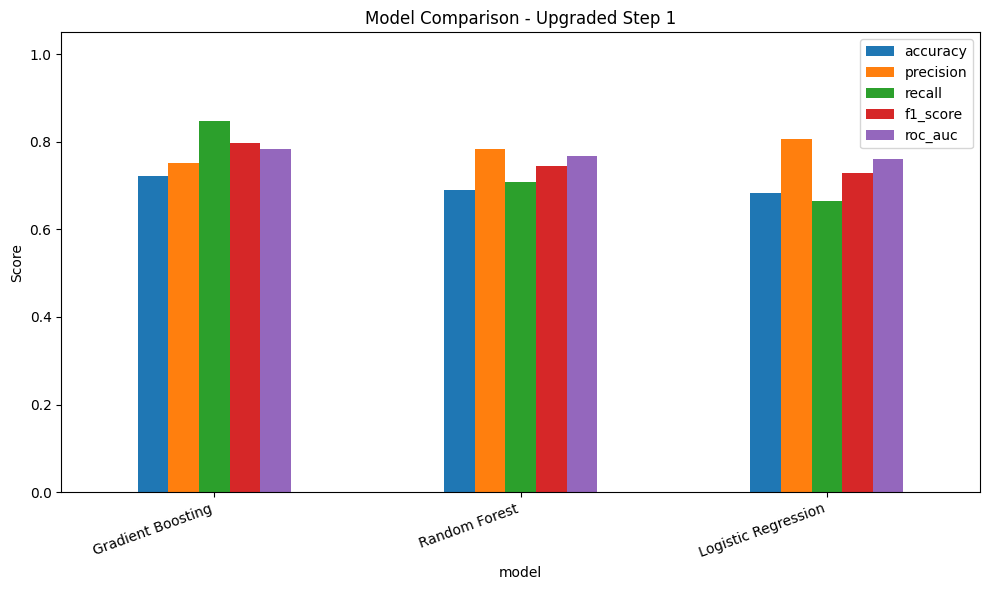

In [17]:
plot_df = results_df[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"]].set_index("model")
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison - Upgraded Step 1")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [18]:
def plot_conf_matrix(cm, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not Delayed", "Delayed"])
    ax.set_yticklabels(["Not Delayed", "Delayed"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

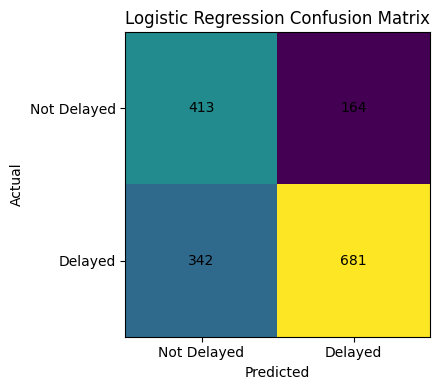

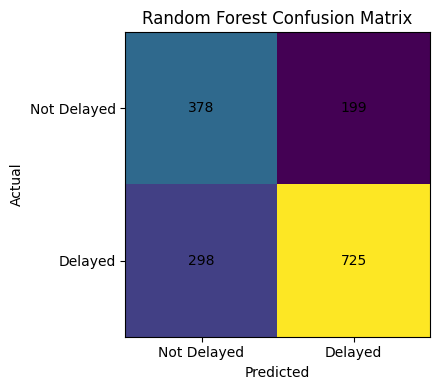

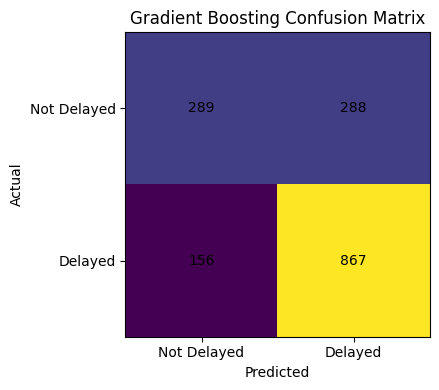

In [19]:
plot_conf_matrix(confusion_matrix(y_test, y_pred_logreg), "Logistic Regression Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_rf), "Random Forest Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_gb), "Gradient Boosting Confusion Matrix")

In [20]:
results_df.to_csv("results/step1_model_results.csv", index=False)
df.to_csv("data/synthetic_supply_chain_data.csv", index=False)

print("Saved files:")
print("- data/synthetic_supply_chain_data.csv")
print("- results/step1_model_results.csv")

Saved files:
- data/synthetic_supply_chain_data.csv
- results/step1_model_results.csv


In [21]:
important_columns = [
    "inventory_level",
    "demand_forecast",
    "supplier_reliability",
    "supplier_lead_time_days",
    "carrier_reliability",
    "weather_severity",
    "shipment_priority",
    "inventory_gap",
    "inventory_coverage_ratio",
    "distance_weather_risk",
    "delivery_pressure",
    "route_disruption_flag",
    "is_delayed"
]

df_engineered[important_columns].head(10)

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,carrier_reliability,weather_severity,shipment_priority,inventory_gap,inventory_coverage_ratio,distance_weather_risk,delivery_pressure,route_disruption_flag,is_delayed
0,122,270,0.72,4,0.75,2,Medium,148,0.451852,2298,191.500000,0,1
1,455,604,0.77,4,0.93,4,Low,149,0.753311,7220,361.000000,0,1
2,290,994,0.70,16,0.80,6,Low,704,0.291751,11580,214.444444,0,1
3,126,853,0.66,5,0.59,0,Medium,727,0.147714,0,495.500000,0,1
4,91,427,0.73,4,0.90,0,Medium,336,0.213115,0,409.714286,0,1
5,720,669,0.56,6,0.77,2,Low,0,1.076233,6340,452.857143,0,0
6,40,315,0.89,3,0.57,3,Medium,275,0.126984,3624,402.666667,0,0
7,634,144,0.63,8,0.91,0,High,0,4.402778,0,236.125000,0,0
8,141,311,0.57,17,0.88,7,Medium,170,0.453376,18886,299.777778,1,1
9,486,874,0.84,18,0.75,1,Low,388,0.556064,2029,405.800000,0,1


In [22]:
best_model = results_df.iloc[0]

print("Step 1 Upgrade Completed Successfully")
print("=" * 50)
print("Best model:", best_model["model"])
print("Best F1 Score:", round(best_model["f1_score"], 4))
print("Best ROC AUC:", round(best_model["roc_auc"], 4))
print("\nThis notebook now includes:")
print("- Upgraded synthetic dataset")
print("- Realistic business features")
print("- Feature engineering")
print("- Logistic Regression")
print("- Random Forest")
print("- Gradient Boosting")
print("- Model evaluation and comparison")

Step 1 Upgrade Completed Successfully
Best model: Gradient Boosting
Best F1 Score: 0.7961
Best ROC AUC: 0.7828

This notebook now includes:
- Upgraded synthetic dataset
- Realistic business features
- Feature engineering
- Logistic Regression
- Random Forest
- Gradient Boosting
- Model evaluation and comparison


In [23]:
%%writefile src/agents.py
class InventoryAgent:
    def analyze(self, row):
        findings = []
        recommended_actions = []
        risk_score = 0
        confidence = 0.50

        inventory_ratio = row.get("inventory_coverage_ratio", row["inventory_level"] / max(row["demand_forecast"], 1))
        supplier_reliability = row["supplier_reliability"]
        warehouse_utilization = row["warehouse_utilization"]
        supplier_lead_time_days = row["supplier_lead_time_days"]

        if inventory_ratio < 0.75:
            findings.append(f"Inventory coverage is low ({inventory_ratio:.2f}) relative to forecasted demand.")
            recommended_actions.append("Trigger replenishment review.")
            risk_score += 2
            confidence += 0.08

        if inventory_ratio < 0.45:
            findings.append("Inventory coverage is critically low.")
            recommended_actions.append("Rebalance stock from alternate warehouse.")
            risk_score += 2
            confidence += 0.08

        if supplier_reliability < 0.75:
            findings.append(f"Supplier reliability is below threshold ({supplier_reliability:.2f}).")
            recommended_actions.append("Evaluate backup supplier options.")
            risk_score += 2
            confidence += 0.07

        if supplier_lead_time_days > 12:
            findings.append(f"Supplier lead time is high ({supplier_lead_time_days} days).")
            recommended_actions.append("Advance reorder planning for this shipment.")
            risk_score += 1
            confidence += 0.05

        if warehouse_utilization > 0.88:
            findings.append(f"Warehouse utilization is elevated ({warehouse_utilization:.2f}).")
            recommended_actions.append("Prioritize picking/packing slot allocation.")
            risk_score += 1
            confidence += 0.05

        if not findings:
            findings.append("No major inventory-side issues detected.")
            recommended_actions.append("Continue standard inventory workflow.")
            confidence = 0.62

        severity = "Low"
        if risk_score >= 5:
            severity = "High"
        elif risk_score >= 3:
            severity = "Medium"

        return {
            "agent": "InventoryAgent",
            "risk_score": risk_score,
            "confidence": round(min(confidence, 0.95), 2),
            "severity": severity,
            "findings": findings,
            "recommended_actions": list(dict.fromkeys(recommended_actions))
        }


class LogisticsAgent:
    def analyze(self, row):
        findings = []
        recommended_actions = []
        risk_score = 0
        confidence = 0.50

        shipping_distance = row["shipping_distance"]
        weather_severity = row["weather_severity"]
        carrier_delay_history = row["carrier_delay_history"]
        carrier_reliability = row["carrier_reliability"]
        processing_time_hours = row["processing_time_hours"]
        promised_delivery_days = row["promised_delivery_days"]
        delivery_pressure = row.get("delivery_pressure", shipping_distance / max(promised_delivery_days, 1))

        if shipping_distance > 1800:
            findings.append(f"Shipping distance is high ({shipping_distance} km).")
            recommended_actions.append("Review expedited routing options.")
            risk_score += 1
            confidence += 0.05

        if weather_severity > 6:
            findings.append(f"Weather severity is elevated ({weather_severity}/10).")
            recommended_actions.append("Increase route monitoring and contingency planning.")
            risk_score += 2
            confidence += 0.08

        if shipping_distance > 1500 and weather_severity > 6:
            findings.append("Long-distance route is exposed to severe weather disruption.")
            recommended_actions.append("Consider rerouting shipment.")
            risk_score += 2
            confidence += 0.08

        if carrier_delay_history > 0.25:
            findings.append(f"Carrier has elevated historical delay rate ({carrier_delay_history:.2f}).")
            recommended_actions.append("Evaluate alternate carrier assignment.")
            risk_score += 1
            confidence += 0.05

        if carrier_reliability < 0.72:
            findings.append(f"Carrier reliability is below safe threshold ({carrier_reliability:.2f}).")
            recommended_actions.append("Escalate carrier performance review.")
            risk_score += 1
            confidence += 0.05

        if processing_time_hours > 42:
            findings.append(f"Processing time is high ({processing_time_hours:.1f} hours).")
            recommended_actions.append("Prioritize fulfillment handling.")
            risk_score += 1
            confidence += 0.05

        if delivery_pressure > 500:
            findings.append(f"Delivery pressure is high ({delivery_pressure:.1f}).")
            recommended_actions.append("Review promise-date feasibility.")
            risk_score += 1
            confidence += 0.04

        if not findings:
            findings.append("No major logistics-side issues detected.")
            recommended_actions.append("Continue standard logistics workflow.")
            confidence = 0.62

        severity = "Low"
        if risk_score >= 5:
            severity = "High"
        elif risk_score >= 3:
            severity = "Medium"

        return {
            "agent": "LogisticsAgent",
            "risk_score": risk_score,
            "confidence": round(min(confidence, 0.95), 2),
            "severity": severity,
            "findings": findings,
            "recommended_actions": list(dict.fromkeys(recommended_actions))
        }


class ManagerAgent:
    def decide_agent_only(self, inventory_report, logistics_report, row=None):
        total_risk = inventory_report["risk_score"] + logistics_report["risk_score"]
        avg_confidence = (inventory_report["confidence"] + logistics_report["confidence"]) / 2

        if inventory_report["risk_score"] > logistics_report["risk_score"]:
            primary_cause = "Inventory constraint"
        elif logistics_report["risk_score"] > inventory_report["risk_score"]:
            primary_cause = "Logistics disruption"
        else:
            primary_cause = "Mixed operational risk"

        prediction = 1 if total_risk >= 5 else 0
        delay_risk = "High" if total_risk >= 6 else "Medium" if total_risk >= 4 else "Low"

        recommended_actions = (
            inventory_report["recommended_actions"] +
            logistics_report["recommended_actions"]
        )
        recommended_actions = list(dict.fromkeys(recommended_actions))

        if prediction == 1:
            reasoning_summary = (
                f"Agent-only decision indicates elevated delay risk driven primarily by {primary_cause.lower()}."
            )
        else:
            reasoning_summary = (
                "Agent-only decision indicates manageable operational risk under current conditions."
            )

        return {
            "prediction": prediction,
            "delay_risk": delay_risk,
            "primary_cause": primary_cause,
            "total_risk": total_risk,
            "confidence": round(avg_confidence, 2),
            "recommended_actions": recommended_actions,
            "reasoning_summary": reasoning_summary
        }

    def decide_with_ml(self, inventory_report, logistics_report, ml_probability, row=None):
        total_risk = inventory_report["risk_score"] + logistics_report["risk_score"]
        avg_confidence = (inventory_report["confidence"] + logistics_report["confidence"]) / 2

        normalized_agent_risk = min(total_risk / 10, 1.0)
        hybrid_score = (0.62 * ml_probability) + (0.28 * normalized_agent_risk) + (0.10 * avg_confidence)

        if inventory_report["risk_score"] > logistics_report["risk_score"]:
            primary_cause = "Inventory constraint"
        elif logistics_report["risk_score"] > inventory_report["risk_score"]:
            primary_cause = "Logistics disruption"
        else:
            primary_cause = "Mixed operational risk"

        prediction = 1 if hybrid_score >= 0.50 else 0
        delay_risk = "High" if hybrid_score >= 0.70 else "Medium" if hybrid_score >= 0.50 else "Low"

        recommended_actions = (
            inventory_report["recommended_actions"] +
            logistics_report["recommended_actions"]
        )
        recommended_actions = list(dict.fromkeys(recommended_actions))

        if prediction == 1:
            reasoning_summary = (
                f"Hybrid decision indicates likely shipment delay. ML probability ({ml_probability:.2f}) "
                f"and agent assessments jointly suggest {primary_cause.lower()} as the dominant risk driver."
            )
        else:
            reasoning_summary = (
                f"Hybrid decision indicates shipment is likely manageable. ML probability ({ml_probability:.2f}) "
                f"and agent assessments remain below escalation threshold."
            )

        return {
            "prediction": prediction,
            "delay_risk": delay_risk,
            "primary_cause": primary_cause,
            "total_risk": total_risk,
            "hybrid_score": round(hybrid_score, 4),
            "confidence": round(avg_confidence, 2),
            "recommended_actions": recommended_actions,
            "reasoning_summary": reasoning_summary
        }

Writing src/agents.py


In [24]:
%%writefile src/orchestrator.py
import numpy as np
import pandas as pd

from src.agents import InventoryAgent, LogisticsAgent, ManagerAgent


def rule_based_predict(row):
    risk = 0

    inventory_ratio = row.get("inventory_coverage_ratio", row["inventory_level"] / max(row["demand_forecast"], 1))
    delivery_pressure = row.get("delivery_pressure", row["shipping_distance"] / max(row["promised_delivery_days"], 1))

    if inventory_ratio < 0.75:
        risk += 2
    if inventory_ratio < 0.45:
        risk += 2
    if row["supplier_reliability"] < 0.75:
        risk += 2
    if row["supplier_lead_time_days"] > 12:
        risk += 1
    if row["warehouse_utilization"] > 0.88:
        risk += 1
    if row["shipping_distance"] > 1800:
        risk += 1
    if row["weather_severity"] > 6:
        risk += 2
    if row["shipping_distance"] > 1500 and row["weather_severity"] > 6:
        risk += 2
    if row["carrier_delay_history"] > 0.25:
        risk += 1
    if row["carrier_reliability"] < 0.72:
        risk += 1
    if row["processing_time_hours"] > 42:
        risk += 1
    if delivery_pressure > 500:
        risk += 1
    if row["is_peak_season"] == 1 and row["product_category"] == "Electronics":
        risk += 1

    return 1 if risk >= 7 else 0


def run_rule_based_system(X_input):
    return X_input.apply(rule_based_predict, axis=1)


def run_agent_only_system(X_input):
    inventory_agent = InventoryAgent()
    logistics_agent = LogisticsAgent()
    manager_agent = ManagerAgent()

    predictions = []
    details = []

    for _, row in X_input.iterrows():
        inv_report = inventory_agent.analyze(row)
        log_report = logistics_agent.analyze(row)
        mgr_report = manager_agent.decide_agent_only(inv_report, log_report, row)

        predictions.append(mgr_report["prediction"])
        details.append({
            "inventory_severity": inv_report["severity"],
            "inventory_confidence": inv_report["confidence"],
            "inventory_findings": " | ".join(inv_report["findings"]),
            "logistics_severity": log_report["severity"],
            "logistics_confidence": log_report["confidence"],
            "logistics_findings": " | ".join(log_report["findings"]),
            "primary_cause": mgr_report["primary_cause"],
            "delay_risk": mgr_report["delay_risk"],
            "total_risk": mgr_report["total_risk"],
            "manager_confidence": mgr_report["confidence"],
            "recommended_actions": " | ".join(mgr_report["recommended_actions"]),
            "reasoning_summary": mgr_report["reasoning_summary"]
        })

    return np.array(predictions), pd.DataFrame(details)


def run_ml_agent_hybrid_system(X_input, ml_probabilities):
    inventory_agent = InventoryAgent()
    logistics_agent = LogisticsAgent()
    manager_agent = ManagerAgent()

    predictions = []
    details = []

    for idx, (_, row) in enumerate(X_input.iterrows()):
        inv_report = inventory_agent.analyze(row)
        log_report = logistics_agent.analyze(row)
        mgr_report = manager_agent.decide_with_ml(inv_report, log_report, ml_probabilities[idx], row)

        predictions.append(mgr_report["prediction"])
        details.append({
            "ml_probability": round(float(ml_probabilities[idx]), 4),
            "inventory_severity": inv_report["severity"],
            "inventory_confidence": inv_report["confidence"],
            "inventory_findings": " | ".join(inv_report["findings"]),
            "logistics_severity": log_report["severity"],
            "logistics_confidence": log_report["confidence"],
            "logistics_findings": " | ".join(log_report["findings"]),
            "primary_cause": mgr_report["primary_cause"],
            "delay_risk": mgr_report["delay_risk"],
            "total_risk": mgr_report["total_risk"],
            "hybrid_score": mgr_report["hybrid_score"],
            "manager_confidence": mgr_report["confidence"],
            "recommended_actions": " | ".join(mgr_report["recommended_actions"]),
            "reasoning_summary": mgr_report["reasoning_summary"]
        })

    return np.array(predictions), pd.DataFrame(details)


def predict_single_shipment(shipment_row, ml_pipeline):
    inventory_agent = InventoryAgent()
    logistics_agent = LogisticsAgent()
    manager_agent = ManagerAgent()

    if isinstance(shipment_row, dict):
        row_df = pd.DataFrame([shipment_row])
    else:
        row_df = shipment_row.copy()

    ml_prob = ml_pipeline.predict_proba(row_df)[:, 1][0]

    inv_report = inventory_agent.analyze(row_df.iloc[0])
    log_report = logistics_agent.analyze(row_df.iloc[0])
    mgr_report = manager_agent.decide_with_ml(inv_report, log_report, ml_prob, row_df.iloc[0])

    return {
        "ml_delay_probability": round(float(ml_prob), 4),
        "inventory_report": inv_report,
        "logistics_report": log_report,
        "manager_decision": mgr_report
    }

Writing src/orchestrator.py


In [25]:
from src.agents import InventoryAgent, LogisticsAgent, ManagerAgent
from src.orchestrator import (
    run_rule_based_system,
    run_agent_only_system,
    run_ml_agent_hybrid_system,
    predict_single_shipment
)
print("Agent and orchestrator modules imported successfully.")

Agent and orchestrator modules imported successfully.


In [26]:
# Using the already-trained Random Forest probabilities from Step 1
y_pred_rule = run_rule_based_system(X_test)
y_pred_agent_only, agent_only_details = run_agent_only_system(X_test)
y_pred_hybrid, hybrid_details = run_ml_agent_hybrid_system(X_test, y_prob_rf)
print("Rule-based, agent-only, and hybrid systems executed successfully.")

Rule-based, agent-only, and hybrid systems executed successfully.


In [27]:
results_rule = evaluate_model("Rule-Based Baseline", y_test, y_pred_rule, y_pred_rule)
results_agent_only = evaluate_model("Agent-Only System", y_test, y_pred_agent_only, y_pred_agent_only)
results_hybrid = evaluate_model("ML + Agent Hybrid System", y_test, y_pred_hybrid, y_prob_rf)


===== Rule-Based Baseline =====
Accuracy : 0.6750
Precision: 0.8376
Recall   : 0.6100
F1 Score : 0.7059
ROC AUC  : 0.7001

Confusion Matrix:
[[456 121]
 [399 624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.79      0.64       577
           1       0.84      0.61      0.71      1023

    accuracy                           0.68      1600
   macro avg       0.69      0.70      0.67      1600
weighted avg       0.73      0.68      0.68      1600


===== Agent-Only System =====
Accuracy : 0.7119
Precision: 0.7496
Recall   : 0.8250
F1 Score : 0.7855
ROC AUC  : 0.6681

Confusion Matrix:
[[295 282]
 [179 844]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.51      0.56       577
           1       0.75      0.83      0.79      1023

    accuracy                           0.71      1600
   macro avg       0.69      0.67      0.67      1600
weighted avg       0.70  

In [28]:
full_results_df = pd.DataFrame([
    results_rule,
    results_agent_only,
    results_logreg,
    results_rf,
    results_gb,
    results_hybrid
])

full_results_df = full_results_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)
full_results_df

,model,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp
0,Gradient Boosting,0.722500,0.750649,0.847507,0.796143,0.782791,289,288,156,867
1,Agent-Only System,0.711875,0.749556,0.825024,0.785482,0.668145,295,282,179,844
2,ML + Agent Hybrid System,0.706875,0.779798,0.754643,0.767014,0.766775,359,218,251,772
3,Random Forest,0.689375,0.784632,0.708700,0.744735,0.766775,378,199,298,725
4,Logistic Regression,0.683750,0.805917,0.665689,0.729122,0.760083,413,164,342,681
5,Rule-Based Baseline,0.675000,0.837584,0.609971,0.705882,0.700133,456,121,399,624


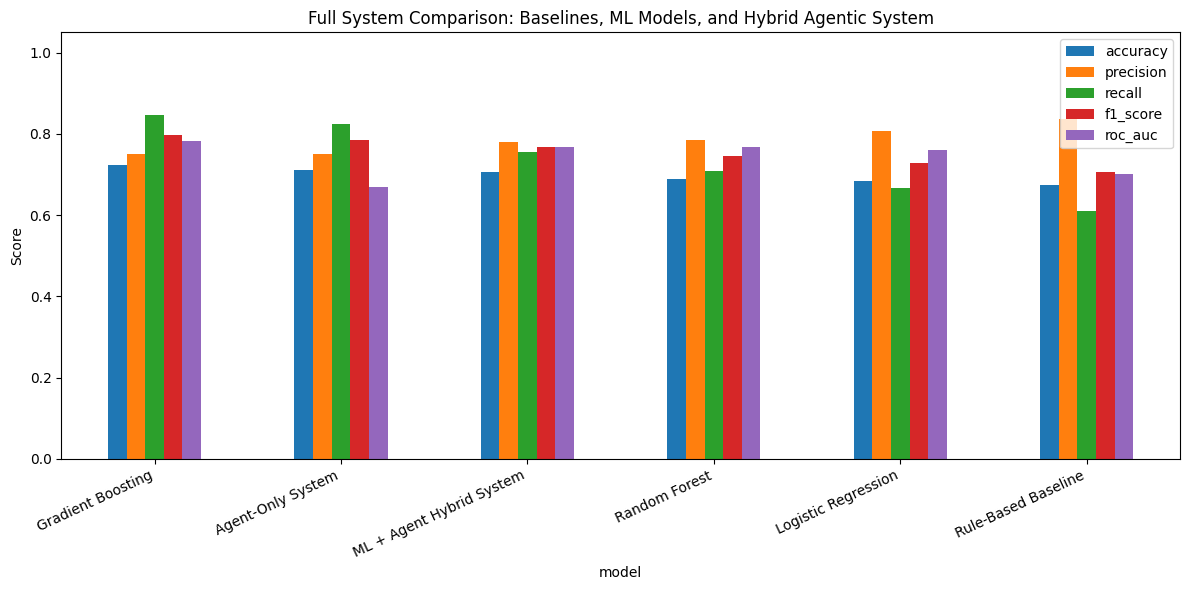

In [29]:
plot_df = full_results_df[
    ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"]
].set_index("model")

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Full System Comparison: Baselines, ML Models, and Hybrid Agentic System")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

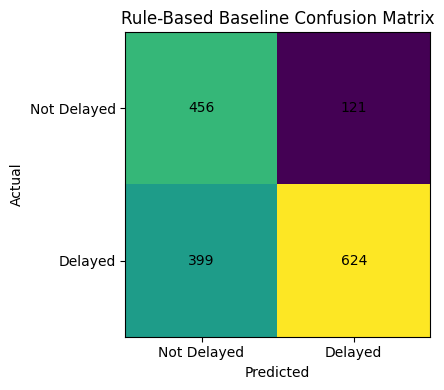

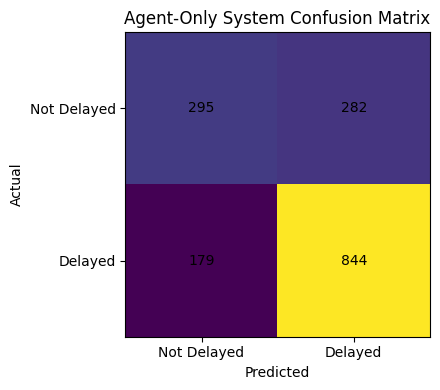

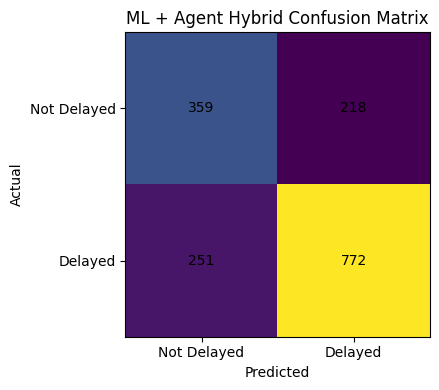

In [30]:
plot_conf_matrix(confusion_matrix(y_test, y_pred_rule), "Rule-Based Baseline Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_agent_only), "Agent-Only System Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_hybrid), "ML + Agent Hybrid Confusion Matrix")

In [31]:
agent_only_details.head(10)

,inventory_severity,inventory_confidence,inventory_findings,logistics_severity,logistics_confidence,logistics_findings,primary_cause,delay_risk,total_risk,manager_confidence,recommended_actions,reasoning_summary
0,Medium,0.62,Supplier reliability is below threshold (0.71)...,Low,0.60,Shipping distance is high (2818 km). | Process...,Inventory constraint,Medium,5,0.61,Evaluate backup supplier options. | Prioritize...,Agent-only decision indicates elevated delay r...
1,High,0.71,Inventory coverage is low (0.30) relative to f...,High,0.80,Shipping distance is high (2039 km). | Weather...,Logistics disruption,High,12,0.76,Trigger replenishment review. | Rebalance stoc...,Agent-only decision indicates elevated delay r...
2,Low,0.58,Inventory coverage is low (0.48) relative to f...,Medium,0.65,Shipping distance is high (3331 km). | Carrier...,Logistics disruption,Medium,5,0.61,Trigger replenishment review. | Review expedit...,Agent-only decision indicates elevated delay r...
3,High,0.73,Inventory coverage is low (0.22) relative to f...,Low,0.60,Carrier reliability is below safe threshold (0...,Inventory constraint,High,8,0.67,Trigger replenishment review. | Rebalance stoc...,Agent-only decision indicates elevated delay r...
4,High,0.78,Inventory coverage is low (0.04) relative to f...,Low,0.62,No major logistics-side issues detected.,Inventory constraint,High,7,0.70,Trigger replenishment review. | Rebalance stoc...,Agent-only decision indicates elevated delay r...
5,Medium,0.66,Inventory coverage is low (0.30) relative to f...,Medium,0.63,Weather severity is elevated (7/10). | Process...,Inventory constraint,High,7,0.65,Trigger replenishment review. | Rebalance stoc...,Agent-only decision indicates elevated delay r...
6,High,0.70,Inventory coverage is low (0.51) relative to f...,High,0.76,Weather severity is elevated (10/10). | Long-d...,Logistics disruption,High,11,0.73,Trigger replenishment review. | Evaluate backu...,Agent-only decision indicates elevated delay r...
7,Medium,0.63,Inventory coverage is low (0.47) relative to f...,Medium,0.69,Shipping distance is high (3270 km). | Carrier...,Logistics disruption,High,7,0.66,Trigger replenishment review. | Advance reorde...,Agent-only decision indicates elevated delay r...
8,High,0.78,Inventory coverage is low (0.21) relative to f...,High,0.90,Shipping distance is high (3058 km). | Weather...,Logistics disruption,High,16,0.84,Trigger replenishment review. | Rebalance stoc...,Agent-only decision indicates elevated delay r...
9,Low,0.60,Supplier lead time is high (15 days). | Wareho...,Medium,0.68,Weather severity is elevated (10/10). | Carrie...,Logistics disruption,High,6,0.64,Advance reorder planning for this shipment. | ...,Agent-only decision indicates elevated delay r...


In [32]:
hybrid_details.head(10)

,ml_probability,inventory_severity,inventory_confidence,inventory_findings,logistics_severity,logistics_confidence,logistics_findings,primary_cause,delay_risk,total_risk,hybrid_score,manager_confidence,recommended_actions,reasoning_summary
0,0.4459,Medium,0.62,Supplier reliability is below threshold (0.71)...,Low,0.60,Shipping distance is high (2818 km). | Process...,Inventory constraint,Low,5,0.4774,0.61,Evaluate backup supplier options. | Prioritize...,Hybrid decision indicates shipment is likely m...
1,0.9162,High,0.71,Inventory coverage is low (0.30) relative to f...,High,0.80,Shipping distance is high (2039 km). | Weather...,Logistics disruption,High,12,0.9235,0.76,Trigger replenishment review. | Rebalance stoc...,Hybrid decision indicates likely shipment dela...
2,0.6080,Low,0.58,Inventory coverage is low (0.48) relative to f...,Medium,0.65,Shipping distance is high (3331 km). | Carrier...,Logistics disruption,Medium,5,0.5785,0.61,Trigger replenishment review. | Review expedit...,Hybrid decision indicates likely shipment dela...
3,0.8282,High,0.73,Inventory coverage is low (0.22) relative to f...,Low,0.60,Carrier reliability is below safe threshold (0...,Inventory constraint,High,8,0.8040,0.67,Trigger replenishment review. | Rebalance stoc...,Hybrid decision indicates likely shipment dela...
4,0.8308,High,0.78,Inventory coverage is low (0.04) relative to f...,Low,0.62,No major logistics-side issues detected.,Inventory constraint,High,7,0.7811,0.70,Trigger replenishment review. | Rebalance stoc...,Hybrid decision indicates likely shipment dela...
5,0.6717,Medium,0.66,Inventory coverage is low (0.30) relative to f...,Medium,0.63,Weather severity is elevated (7/10). | Process...,Inventory constraint,Medium,7,0.6769,0.65,Trigger replenishment review. | Rebalance stoc...,Hybrid decision indicates likely shipment dela...
6,0.8699,High,0.70,Inventory coverage is low (0.51) relative to f...,High,0.76,Weather severity is elevated (10/10). | Long-d...,Logistics disruption,High,11,0.8923,0.73,Trigger replenishment review. | Evaluate backu...,Hybrid decision indicates likely shipment dela...
7,0.6104,Medium,0.63,Inventory coverage is low (0.47) relative to f...,Medium,0.69,Shipping distance is high (3270 km). | Carrier...,Logistics disruption,Medium,7,0.6404,0.66,Trigger replenishment review. | Advance reorde...,Hybrid decision indicates likely shipment dela...
8,0.9506,High,0.78,Inventory coverage is low (0.21) relative to f...,High,0.90,Shipping distance is high (3058 km). | Weather...,Logistics disruption,High,16,0.9534,0.84,Trigger replenishment review. | Rebalance stoc...,Hybrid decision indicates likely shipment dela...
9,0.4667,Low,0.60,Supplier lead time is high (15 days). | Wareho...,Medium,0.68,Weather severity is elevated (10/10). | Carrie...,Logistics disruption,Medium,6,0.5214,0.64,Advance reorder planning for this shipment. | ...,Hybrid decision indicates likely shipment dela...


In [33]:
comparison_view = X_test.head(15).copy()
comparison_view["actual"] = y_test.head(15).values
comparison_view["rule_based_pred"] = y_pred_rule.head(15).values
comparison_view["agent_only_pred"] = y_pred_agent_only[:15]
comparison_view["rf_pred"] = y_pred_rf[:15]
comparison_view["hybrid_pred"] = y_pred_hybrid[:15]
comparison_view["rf_probability"] = y_prob_rf[:15]

comparison_view

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,electronics_peak_flag,grocery_weather_flag,severe_inventory_flag,route_disruption_flag,actual,rule_based_pred,agent_only_pred,rf_pred,hybrid_pred,rf_probability
2051,618,381,0.71,12,0.91,2818,0,0.24,0.74,90.6,...,0,0,0,0,1,0,1,0,0,0.445876
546,187,633,0.76,20,0.78,2039,9,0.22,0.86,57.2,...,0,0,1,1,1,1,1,1,1,0.916202
5323,439,912,0.87,5,0.63,3331,1,0.30,0.94,67.4,...,0,0,0,0,1,0,1,1,1,0.608025
5732,130,579,0.62,6,0.84,1361,1,0.17,0.55,75.5,...,0,0,1,0,1,1,1,1,1,0.828179
737,31,765,0.59,15,0.72,805,1,0.09,0.80,36.3,...,0,0,1,0,1,1,1,1,1,0.830808
7007,228,753,0.85,9,0.79,360,7,0.25,0.78,70.0,...,0,0,1,0,1,1,1,1,1,0.671693
5335,490,964,0.61,13,0.68,1659,10,0.02,0.57,78.9,...,0,1,0,1,1,1,1,1,1,0.869912
4339,387,817,0.82,16,0.56,3270,5,0.07,0.62,61.2,...,0,0,0,0,1,1,1,1,1,0.610383
5467,77,371,0.59,14,0.54,3058,8,0.39,0.68,49.1,...,0,0,1,1,1,1,1,1,1,0.950615
256,771,558,0.98,15,0.92,1481,10,0.33,0.97,80.3,...,0,0,0,0,1,0,1,0,1,0.466706


In [34]:
sample_shipment = {
    "inventory_level": 120,
    "demand_forecast": 540,
    "supplier_reliability": 0.66,
    "supplier_lead_time_days": 15,
    "warehouse_utilization": 0.91,
    "shipping_distance": 2200,
    "weather_severity": 8,
    "carrier_delay_history": 0.31,
    "carrier_reliability": 0.68,
    "processing_time_hours": 48.0,
    "promised_delivery_days": 4,
    "week_of_year": 48,
    "warehouse_region": "East",
    "product_category": "Electronics",
    "shipment_priority": "High",
    "is_peak_season": 1,
    "inventory_to_demand_ratio": 120 / 540,
    "inventory_gap": max(540 - 120, 0),
    "inventory_coverage_ratio": 120 / 540,
    "supplier_risk_score": 1 - 0.66,
    "carrier_risk_score": 1 - 0.68,
    "distance_weather_risk": 2200 * 8,
    "warehouse_processing_risk": 0.91 * 48.0,
    "supplier_inventory_risk": (1 - 0.66) * (1 / max(120 / 540, 0.05)),
    "carrier_distance_risk": 0.31 * 2200,
    "delivery_pressure": 2200 / 4,
    "lead_time_pressure": 15 / 4,
    "shipment_priority_encoded": 2,
    "electronics_peak_flag": 1,
    "grocery_weather_flag": 0,
    "severe_inventory_flag": 1,
    "route_disruption_flag": 1
}

In [35]:
demo_result = predict_single_shipment(sample_shipment, rf_model)
demo_result

{'ml_delay_probability': 0.9729,
 'inventory_report': {'agent': 'InventoryAgent',
  'risk_score': 8,
  'confidence': 0.83,
  'severity': 'High',
  'findings': ['Inventory coverage is low (0.22) relative to forecasted demand.',
   'Inventory coverage is critically low.',
   'Supplier reliability is below threshold (0.66).',
   'Supplier lead time is high (15 days).',
   'Warehouse utilization is elevated (0.91).'],
  'recommended_actions': ['Trigger replenishment review.',
   'Rebalance stock from alternate warehouse.',
   'Evaluate backup supplier options.',
   'Advance reorder planning for this shipment.',
   'Prioritize picking/packing slot allocation.']},
 'logistics_report': {'agent': 'LogisticsAgent',
  'risk_score': 9,
  'confidence': 0.9,
  'severity': 'High',
  'findings': ['Shipping distance is high (2200 km).',
   'Weather severity is elevated (8/10).',
   'Long-distance route is exposed to severe weather disruption.',
   'Carrier has elevated historical delay rate (0.31).',


In [36]:
print("ML Delay Probability:", demo_result["ml_delay_probability"])
print("\nInventory Report:")
print(demo_result["inventory_report"])
print("\nLogistics Report:")
print(demo_result["logistics_report"])
print("\nManager Decision:")
print(demo_result["manager_decision"])

ML Delay Probability: 0.9729

Inventory Report:
{'agent': 'InventoryAgent', 'risk_score': 8, 'confidence': 0.83, 'severity': 'High', 'findings': ['Inventory coverage is low (0.22) relative to forecasted demand.', 'Inventory coverage is critically low.', 'Supplier reliability is below threshold (0.66).', 'Supplier lead time is high (15 days).', 'Warehouse utilization is elevated (0.91).'], 'recommended_actions': ['Trigger replenishment review.', 'Rebalance stock from alternate warehouse.', 'Evaluate backup supplier options.', 'Advance reorder planning for this shipment.', 'Prioritize picking/packing slot allocation.']}

Logistics Report:
{'agent': 'LogisticsAgent', 'risk_score': 9, 'confidence': 0.9, 'severity': 'High', 'findings': ['Shipping distance is high (2200 km).', 'Weather severity is elevated (8/10).', 'Long-distance route is exposed to severe weather disruption.', 'Carrier has elevated historical delay rate (0.31).', 'Carrier reliability is below safe threshold (0.68).', 'Proc

In [37]:
agent_only_details.to_csv("results/step2_agent_only_details.csv", index=False)
hybrid_details.to_csv("results/step2_hybrid_details.csv", index=False)
full_results_df.to_csv("results/full_system_comparison.csv", index=False)

print("Saved files:")
print("- results/step2_agent_only_details.csv")
print("- results/step2_hybrid_details.csv")
print("- results/full_system_comparison.csv")

Saved files:
- results/step2_agent_only_details.csv
- results/step2_hybrid_details.csv
- results/full_system_comparison.csv


In [38]:
summary_metrics = full_results_df[["model", "precision", "recall", "f1_score"]].copy()
summary_metrics["false_negative_rate"] = (
    full_results_df["fn"] / (full_results_df["fn"] + full_results_df["tp"])
).round(4)

summary_metrics.sort_values(by="f1_score", ascending=False)

,model,precision,recall,f1_score,false_negative_rate
0,Gradient Boosting,0.750649,0.847507,0.796143,0.1525
1,Agent-Only System,0.749556,0.825024,0.785482,0.1750
2,ML + Agent Hybrid System,0.779798,0.754643,0.767014,0.2454
3,Random Forest,0.784632,0.708700,0.744735,0.2913
4,Logistic Regression,0.805917,0.665689,0.729122,0.3343
5,Rule-Based Baseline,0.837584,0.609971,0.705882,0.3900


In [39]:
best_system = full_results_df.iloc[0]

print("Step 2 Upgrade Completed Successfully")
print("=" * 60)
print("Best performing system:", best_system["model"])
print("Accuracy :", round(best_system["accuracy"], 4))
print("Precision:", round(best_system["precision"], 4))
print("Recall   :", round(best_system["recall"], 4))
print("F1 Score :", round(best_system["f1_score"], 4))
print("ROC AUC  :", round(best_system["roc_auc"], 4))
print("\nThis notebook now includes:")
print("- Rule-based baseline")
print("- Agent-only system")
print("- ML models")
print("- ML + Agent hybrid system")
print("- Root-cause analysis")
print("- Agent findings and recommendations")
print("- Business-style evaluation comparison")

Step 2 Upgrade Completed Successfully
Best performing system: Gradient Boosting
Accuracy : 0.7225
Precision: 0.7506
Recall   : 0.8475
F1 Score : 0.7961
ROC AUC  : 0.7828

This notebook now includes:
- Rule-based baseline
- Agent-only system
- ML models
- ML + Agent hybrid system
- Root-cause analysis
- Agent findings and recommendations
- Business-style evaluation comparison


In [40]:
from sklearn.metrics import precision_recall_curve, roc_curve

In [41]:
def get_feature_names_from_preprocessor(preprocessor, X_sample):
    numeric_cols = X_sample.select_dtypes(exclude=["object"]).columns.tolist()
    categorical_cols = X_sample.select_dtypes(include=["object"]).columns.tolist()

    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_cols)

    if "cat" in preprocessor.named_transformers_:
        encoder = preprocessor.named_transformers_["cat"]
        encoded_cat_names = encoder.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(encoded_cat_names)

    return feature_names

In [42]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

rf_feature_names = get_feature_names_from_preprocessor(rf_preprocessor, X_train)

feature_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_estimator.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(20)

,feature,importance
0,inventory_coverage_ratio,0.098213
1,inventory_to_demand_ratio,0.084923
2,supplier_inventory_risk,0.074120
3,inventory_gap,0.056669
4,distance_weather_risk,0.049433
5,supplier_reliability,0.044367
6,inventory_level,0.040210
7,warehouse_processing_risk,0.040119
8,supplier_risk_score,0.039256
9,warehouse_utilization,0.036498


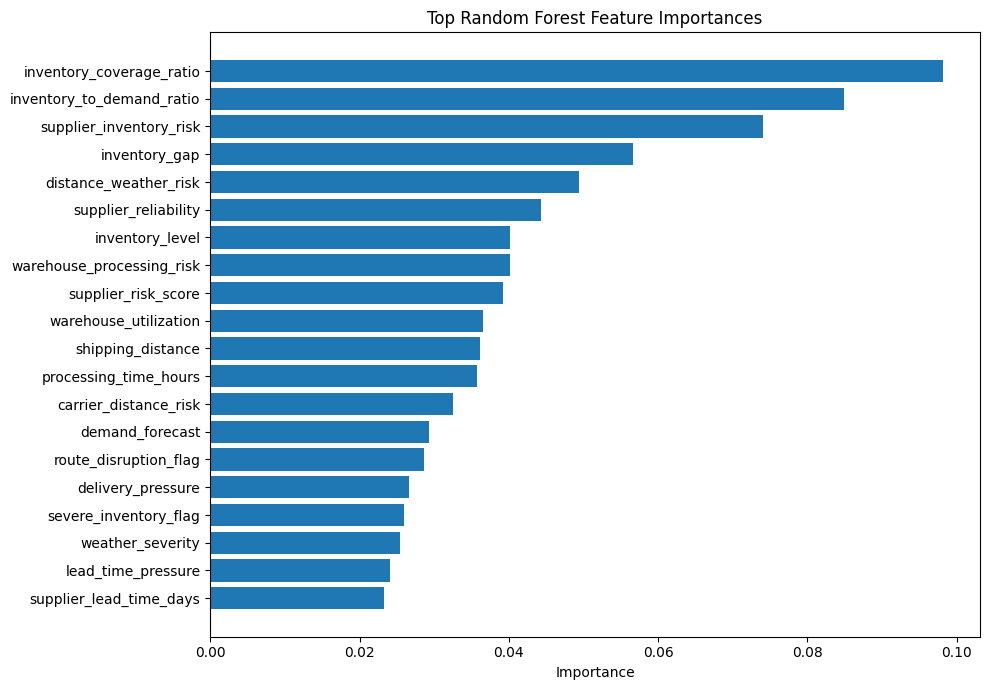

In [43]:
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [44]:
feature_importance_df.to_csv("results/feature_importance.csv", index=False)
print("Saved: results/feature_importance.csv")

Saved: results/feature_importance.csv


In [45]:
def evaluate_thresholds(y_true, y_prob, thresholds):
    rows = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        rows.append({
            "threshold": round(threshold, 2),
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "false_negative_rate": fnr,
            "false_positive_rate": fpr,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    return pd.DataFrame(rows)

In [46]:
thresholds = np.arange(0.30, 0.76, 0.05)
threshold_results_df = evaluate_thresholds(y_test, y_prob_rf, thresholds)
threshold_results_df

,threshold,accuracy,precision,recall,f1_score,false_negative_rate,false_positive_rate,tn,fp,fn,tp
0,0.30,0.706875,0.704277,0.933529,0.802858,0.066471,0.694974,176,401,68,955
1,0.35,0.716250,0.727418,0.889541,0.800352,0.110459,0.590988,236,341,113,910
2,0.40,0.717500,0.748910,0.839687,0.791705,0.160313,0.499133,289,288,164,859
3,0.45,0.708125,0.773084,0.769306,0.771191,0.230694,0.400347,346,231,236,787
4,0.50,0.689375,0.784632,0.708700,0.744735,0.291300,0.344887,378,199,298,725
5,0.55,0.681875,0.805952,0.661779,0.726785,0.338221,0.282496,414,163,346,677
6,0.60,0.666250,0.817945,0.614858,0.702009,0.385142,0.242634,437,140,394,629
7,0.65,0.644375,0.841867,0.546432,0.662715,0.453568,0.181976,472,105,464,559
8,0.70,0.608750,0.860254,0.463343,0.602287,0.536657,0.133449,500,77,549,474
9,0.75,0.583125,0.906393,0.388074,0.543463,0.611926,0.071057,536,41,626,397


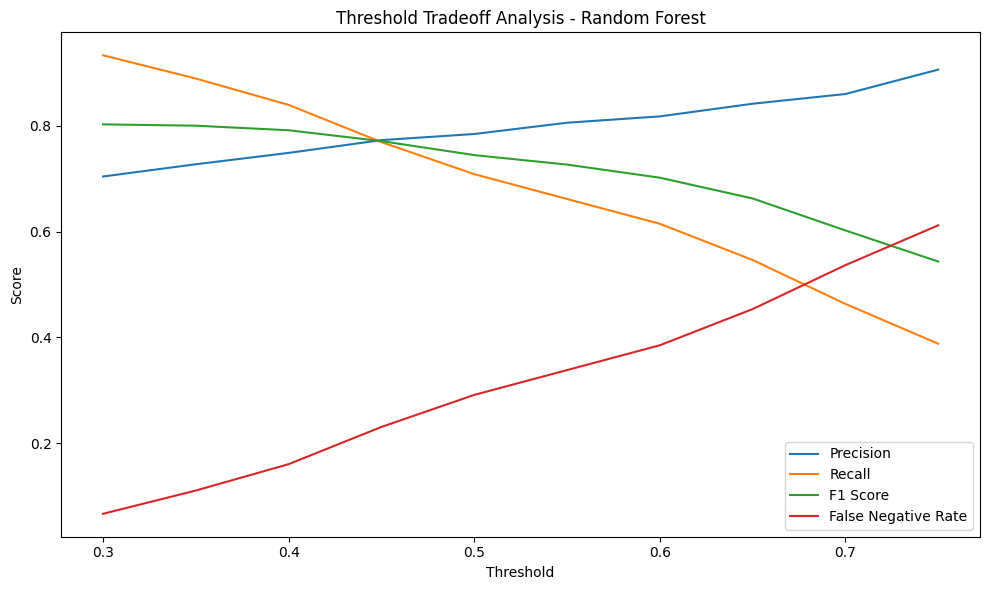

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1_score"], label="F1 Score")
plt.plot(threshold_results_df["threshold"], threshold_results_df["false_negative_rate"], label="False Negative Rate")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff Analysis - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
business_threshold = 0.45
y_pred_rf_tuned = (y_prob_rf >= business_threshold).astype(int)

results_rf_tuned = evaluate_model(
    f"Random Forest (Threshold={business_threshold})",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf
)


===== Random Forest (Threshold=0.45) =====
Accuracy : 0.7081
Precision: 0.7731
Recall   : 0.7693
F1 Score : 0.7712
ROC AUC  : 0.7668

Confusion Matrix:
[[346 231]
 [236 787]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.60      0.60       577
           1       0.77      0.77      0.77      1023

    accuracy                           0.71      1600
   macro avg       0.68      0.68      0.68      1600
weighted avg       0.71      0.71      0.71      1600



In [49]:
full_results_with_tuned_df = pd.DataFrame([
    results_rule,
    results_agent_only,
    results_logreg,
    results_rf,
    results_rf_tuned,
    results_gb,
    results_hybrid
])

full_results_with_tuned_df = full_results_with_tuned_df.sort_values(
    by="f1_score", ascending=False
).reset_index(drop=True)

full_results_with_tuned_df

,model,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp
0,Gradient Boosting,0.722500,0.750649,0.847507,0.796143,0.782791,289,288,156,867
1,Agent-Only System,0.711875,0.749556,0.825024,0.785482,0.668145,295,282,179,844
2,Random Forest (Threshold=0.45),0.708125,0.773084,0.769306,0.771191,0.766775,346,231,236,787
3,ML + Agent Hybrid System,0.706875,0.779798,0.754643,0.767014,0.766775,359,218,251,772
4,Random Forest,0.689375,0.784632,0.708700,0.744735,0.766775,378,199,298,725
5,Logistic Regression,0.683750,0.805917,0.665689,0.729122,0.760083,413,164,342,681
6,Rule-Based Baseline,0.675000,0.837584,0.609971,0.705882,0.700133,456,121,399,624


In [50]:
error_analysis_df = X_test.copy().reset_index(drop=True)
error_analysis_df["actual"] = y_test.reset_index(drop=True)
error_analysis_df["rf_probability"] = y_prob_rf
error_analysis_df["rf_pred_default"] = y_pred_rf
error_analysis_df["rf_pred_tuned"] = y_pred_rf_tuned
error_analysis_df["hybrid_pred"] = y_pred_hybrid

error_analysis_df["rf_default_error_type"] = np.where(
    (error_analysis_df["actual"] == 1) & (error_analysis_df["rf_pred_default"] == 0), "False Negative",
    np.where(
        (error_analysis_df["actual"] == 0) & (error_analysis_df["rf_pred_default"] == 1), "False Positive",
        "Correct"
    )
)

error_analysis_df["hybrid_error_type"] = np.where(
    (error_analysis_df["actual"] == 1) & (error_analysis_df["hybrid_pred"] == 0), "False Negative",
    np.where(
        (error_analysis_df["actual"] == 0) & (error_analysis_df["hybrid_pred"] == 1), "False Positive",
        "Correct"
    )
)

error_analysis_df.head()

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,grocery_weather_flag,severe_inventory_flag,route_disruption_flag,actual,rf_probability,rf_pred_default,rf_pred_tuned,hybrid_pred,rf_default_error_type,hybrid_error_type
0,618,381,0.71,12,0.91,2818,0,0.24,0.74,90.6,...,0,0,0,1,0.445876,0,0,0,False Negative,False Negative
1,187,633,0.76,20,0.78,2039,9,0.22,0.86,57.2,...,0,1,1,1,0.916202,1,1,1,Correct,Correct
2,439,912,0.87,5,0.63,3331,1,0.30,0.94,67.4,...,0,0,0,1,0.608025,1,1,1,Correct,Correct
3,130,579,0.62,6,0.84,1361,1,0.17,0.55,75.5,...,0,1,0,1,0.828179,1,1,1,Correct,Correct
4,31,765,0.59,15,0.72,805,1,0.09,0.80,36.3,...,0,1,0,1,0.830808,1,1,1,Correct,Correct


In [51]:
print("Random Forest default error distribution:")
print(error_analysis_df["rf_default_error_type"].value_counts())
print("\nHybrid system error distribution:")
print(error_analysis_df["hybrid_error_type"].value_counts())

Random Forest default error distribution:
rf_default_error_type
Correct           1103
False Negative     298
False Positive     199
Name: count, dtype: int64

Hybrid system error distribution:
hybrid_error_type
Correct           1131
False Negative     251
False Positive     218
Name: count, dtype: int64


In [52]:
rf_false_negatives = error_analysis_df[error_analysis_df["rf_default_error_type"] == "False Negative"]
rf_false_negatives.head(10)

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,grocery_weather_flag,severe_inventory_flag,route_disruption_flag,actual,rf_probability,rf_pred_default,rf_pred_tuned,hybrid_pred,rf_default_error_type,hybrid_error_type
0,618,381,0.71,12,0.91,2818,0,0.24,0.74,90.6,...,0,0,0,1,0.445876,0,0,0,False Negative,False Negative
9,771,558,0.98,15,0.92,1481,10,0.33,0.97,80.3,...,0,0,0,1,0.466706,0,1,1,False Negative,Correct
12,302,145,0.98,11,0.84,707,8,0.16,0.73,38.8,...,0,0,0,1,0.422379,0,0,0,False Negative,False Negative
17,727,251,0.57,16,0.72,588,10,0.43,0.88,35.6,...,0,0,0,1,0.454902,0,1,1,False Negative,Correct
18,282,373,0.74,3,0.45,507,6,0.18,0.94,68.6,...,0,0,0,1,0.399823,0,0,0,False Negative,False Negative
19,667,171,0.84,3,0.90,2886,0,0.44,0.98,14.7,...,0,0,0,1,0.320813,0,0,0,False Negative,False Negative
23,402,102,0.87,3,0.90,2446,0,0.04,0.58,27.2,...,0,0,0,1,0.333989,0,0,0,False Negative,False Negative
28,460,485,0.55,1,0.81,251,3,0.18,0.75,44.3,...,0,0,0,1,0.310837,0,0,0,False Negative,False Negative
30,791,525,0.80,9,0.69,393,3,0.13,0.56,65.5,...,0,0,0,1,0.238768,0,0,0,False Negative,False Negative
49,692,898,0.90,14,0.55,3379,2,0.03,0.90,76.2,...,0,0,0,1,0.396973,0,0,0,False Negative,False Negative


In [53]:
rf_false_positives = error_analysis_df[error_analysis_df["rf_default_error_type"] == "False Positive"]
rf_false_positives.head(10)

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,grocery_weather_flag,severe_inventory_flag,route_disruption_flag,actual,rf_probability,rf_pred_default,rf_pred_tuned,hybrid_pred,rf_default_error_type,hybrid_error_type
20,117,167,0.82,13,0.61,985,8,0.39,0.66,53.7,...,0,0,0,0,0.602402,1,1,1,False Positive,False Positive
31,496,803,0.72,11,0.76,162,8,0.05,0.77,93.3,...,0,0,0,0,0.655849,1,1,1,False Positive,False Positive
33,297,577,0.98,4,0.84,2394,0,0.41,0.93,34.6,...,0,0,0,0,0.612121,1,1,1,False Positive,False Positive
37,443,562,0.78,10,0.60,2421,10,0.01,0.69,41.9,...,0,0,1,0,0.547345,1,1,1,False Positive,False Positive
52,676,539,0.55,11,0.80,2173,5,0.43,0.77,60.5,...,0,0,0,0,0.534766,1,1,1,False Positive,False Positive
55,708,763,0.80,10,0.77,2637,8,0.09,0.90,91.1,...,0,0,1,0,0.582858,1,1,1,False Positive,False Positive
61,87,967,0.63,4,0.64,2214,5,0.34,0.93,19.1,...,0,1,0,0,0.911702,1,1,1,False Positive,False Positive
71,300,581,0.96,8,0.68,1127,4,0.41,0.92,18.5,...,0,0,0,0,0.572287,1,1,0,False Positive,Correct
74,427,700,0.67,4,0.73,155,6,0.19,0.98,81.9,...,0,0,0,0,0.748672,1,1,1,False Positive,False Positive
75,102,798,0.93,8,0.67,3146,4,0.42,0.82,89.7,...,0,1,0,0,0.703029,1,1,1,False Positive,False Positive


In [54]:
hybrid_false_negatives = error_analysis_df[error_analysis_df["hybrid_error_type"] == "False Negative"]
hybrid_false_negatives.head(10)

,inventory_level,demand_forecast,supplier_reliability,supplier_lead_time_days,warehouse_utilization,shipping_distance,weather_severity,carrier_delay_history,carrier_reliability,processing_time_hours,...,grocery_weather_flag,severe_inventory_flag,route_disruption_flag,actual,rf_probability,rf_pred_default,rf_pred_tuned,hybrid_pred,rf_default_error_type,hybrid_error_type
0,618,381,0.71,12,0.91,2818,0,0.24,0.74,90.6,...,0,0,0,1,0.445876,0,0,0,False Negative,False Negative
12,302,145,0.98,11,0.84,707,8,0.16,0.73,38.8,...,0,0,0,1,0.422379,0,0,0,False Negative,False Negative
18,282,373,0.74,3,0.45,507,6,0.18,0.94,68.6,...,0,0,0,1,0.399823,0,0,0,False Negative,False Negative
19,667,171,0.84,3,0.90,2886,0,0.44,0.98,14.7,...,0,0,0,1,0.320813,0,0,0,False Negative,False Negative
23,402,102,0.87,3,0.90,2446,0,0.04,0.58,27.2,...,0,0,0,1,0.333989,0,0,0,False Negative,False Negative
28,460,485,0.55,1,0.81,251,3,0.18,0.75,44.3,...,0,0,0,1,0.310837,0,0,0,False Negative,False Negative
30,791,525,0.80,9,0.69,393,3,0.13,0.56,65.5,...,0,0,0,1,0.238768,0,0,0,False Negative,False Negative
49,692,898,0.90,14,0.55,3379,2,0.03,0.90,76.2,...,0,0,0,1,0.396973,0,0,0,False Negative,False Negative
68,697,123,0.67,6,0.86,1721,1,0.21,0.63,94.6,...,0,0,0,1,0.401347,0,0,0,False Negative,False Negative
69,139,175,0.97,5,0.97,1252,1,0.12,0.61,92.6,...,0,0,0,1,0.476666,0,1,0,False Negative,False Negative


In [55]:
def slice_performance(df, actual_col, pred_col, slice_col):
    rows = []

    for value in sorted(df[slice_col].dropna().unique()):
        subset = df[df[slice_col] == value]
        if len(subset) == 0:
            continue

        acc = accuracy_score(subset[actual_col], subset[pred_col])
        prec = precision_score(subset[actual_col], subset[pred_col], zero_division=0)
        rec = recall_score(subset[actual_col], subset[pred_col], zero_division=0)
        f1 = f1_score(subset[actual_col], subset[pred_col], zero_division=0)

        rows.append({
            "slice_column": slice_col,
            "slice_value": value,
            "count": len(subset),
            "accuracy": round(acc, 4),
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1_score": round(f1, 4)
        })

    return pd.DataFrame(rows)

In [56]:
slice_priority_rf = slice_performance(error_analysis_df, "actual", "rf_pred_default", "shipment_priority")
slice_priority_hybrid = slice_performance(error_analysis_df, "actual", "hybrid_pred", "shipment_priority")

print("Random Forest by shipment priority")
display(slice_priority_rf)

print("Hybrid System by shipment priority")
display(slice_priority_hybrid)

Random Forest by shipment priority


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,shipment_priority,High,313,0.7220,0.7514,0.7722,0.7616
1,shipment_priority,Low,474,0.6772,0.8022,0.6887,0.7411
2,shipment_priority,Medium,813,0.6839,0.7876,0.6990,0.7407


Hybrid System by shipment priority


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,shipment_priority,High,313,0.7188,0.7371,0.7944,0.7647
1,shipment_priority,Low,474,0.6920,0.7945,0.7296,0.7607
2,shipment_priority,Medium,813,0.7109,0.7877,0.7562,0.7716


In [57]:
slice_category_rf = slice_performance(error_analysis_df, "actual", "rf_pred_default", "product_category")
slice_category_hybrid = slice_performance(error_analysis_df, "actual", "hybrid_pred", "product_category")

print("Random Forest by product category")
display(slice_category_rf)

print("Hybrid System by product category")
display(slice_category_hybrid)

Random Forest by product category


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,product_category,Apparel,325,0.6769,0.7692,0.6897,0.7273
1,product_category,Beauty,312,0.6474,0.7586,0.6600,0.7059
2,product_category,Electronics,390,0.6949,0.8125,0.7027,0.7536
3,product_category,Groceries,273,0.7399,0.8177,0.7957,0.8065
4,product_category,Home,300,0.6933,0.7546,0.7029,0.7278


Hybrid System by product category


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,product_category,Apparel,325,0.7200,0.7667,0.7931,0.7797
1,product_category,Beauty,312,0.6667,0.7553,0.7100,0.7320
2,product_category,Electronics,390,0.6872,0.8044,0.6988,0.7479
3,product_category,Groceries,273,0.7509,0.8138,0.8226,0.8182
4,product_category,Home,300,0.7200,0.7542,0.7714,0.7627


In [58]:
slice_category_rf = slice_performance(error_analysis_df, "actual", "rf_pred_default", "product_category")
slice_category_hybrid = slice_performance(error_analysis_df, "actual", "hybrid_pred", "product_category")

print("Random Forest by product category")
display(slice_category_rf)

print("Hybrid System by product category")
display(slice_category_hybrid)

Random Forest by product category


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,product_category,Apparel,325,0.6769,0.7692,0.6897,0.7273
1,product_category,Beauty,312,0.6474,0.7586,0.6600,0.7059
2,product_category,Electronics,390,0.6949,0.8125,0.7027,0.7536
3,product_category,Groceries,273,0.7399,0.8177,0.7957,0.8065
4,product_category,Home,300,0.6933,0.7546,0.7029,0.7278


Hybrid System by product category


,slice_column,slice_value,count,accuracy,precision,recall,f1_score
0,product_category,Apparel,325,0.7200,0.7667,0.7931,0.7797
1,product_category,Beauty,312,0.6667,0.7553,0.7100,0.7320
2,product_category,Electronics,390,0.6872,0.8044,0.6988,0.7479
3,product_category,Groceries,273,0.7509,0.8138,0.8226,0.8182
4,product_category,Home,300,0.7200,0.7542,0.7714,0.7627


In [59]:
def high_priority_recall(df, actual_col, pred_col):
    subset = df[df["shipment_priority"] == "High"]
    rec = recall_score(subset[actual_col], subset[pred_col], zero_division=0)
    return round(rec, 4), len(subset)

In [60]:
rf_high_priority_recall, rf_high_count = high_priority_recall(error_analysis_df, "actual", "rf_pred_default")
hybrid_high_priority_recall, hybrid_high_count = high_priority_recall(error_analysis_df, "actual", "hybrid_pred")
rf_tuned_high_priority_recall, _ = high_priority_recall(error_analysis_df, "actual", "rf_pred_tuned")

priority_business_df = pd.DataFrame({
    "system": ["Random Forest Default", "Random Forest Tuned", "Hybrid System"],
    "high_priority_recall": [
        rf_high_priority_recall,
        rf_tuned_high_priority_recall,
        hybrid_high_priority_recall
    ],
    "high_priority_sample_count": [rf_high_count, rf_high_count, rf_high_count]
})

priority_business_df

,system,high_priority_recall,high_priority_sample_count
0,Random Forest Default,0.7722,313
1,Random Forest Tuned,0.8167,313
2,Hybrid System,0.7944,313


In [61]:
fn_compare_df = full_results_with_tuned_df[["model", "fn", "tp"]].copy()
fn_compare_df["false_negative_rate"] = (fn_compare_df["fn"] / (fn_compare_df["fn"] + fn_compare_df["tp"])).round(4)
fn_compare_df.sort_values(by="false_negative_rate")

,model,fn,tp,false_negative_rate
0,Gradient Boosting,156,867,0.1525
1,Agent-Only System,179,844,0.1750
2,Random Forest (Threshold=0.45),236,787,0.2307
3,ML + Agent Hybrid System,251,772,0.2454
4,Random Forest,298,725,0.2913
5,Logistic Regression,342,681,0.3343
6,Rule-Based Baseline,399,624,0.3900


In [62]:
business_eval_df = full_results_with_tuned_df[[
    "model", "precision", "recall", "f1_score", "fn", "fp", "tp", "tn"
]].copy()

business_eval_df["false_negative_rate"] = (
    business_eval_df["fn"] / (business_eval_df["fn"] + business_eval_df["tp"])
).round(4)

business_eval_df["false_positive_rate"] = (
    business_eval_df["fp"] / (business_eval_df["fp"] + business_eval_df["tn"])
).round(4)

business_eval_df.sort_values(by=["recall", "f1_score"], ascending=False)

,model,precision,recall,f1_score,fn,fp,tp,tn,false_negative_rate,false_positive_rate
0,Gradient Boosting,0.750649,0.847507,0.796143,156,288,867,289,0.1525,0.4991
1,Agent-Only System,0.749556,0.825024,0.785482,179,282,844,295,0.1750,0.4887
2,Random Forest (Threshold=0.45),0.773084,0.769306,0.771191,236,231,787,346,0.2307,0.4003
3,ML + Agent Hybrid System,0.779798,0.754643,0.767014,251,218,772,359,0.2454,0.3778
4,Random Forest,0.784632,0.708700,0.744735,298,199,725,378,0.2913,0.3449
5,Logistic Regression,0.805917,0.665689,0.729122,342,164,681,413,0.3343,0.2842
6,Rule-Based Baseline,0.837584,0.609971,0.705882,399,121,624,456,0.3900,0.2097


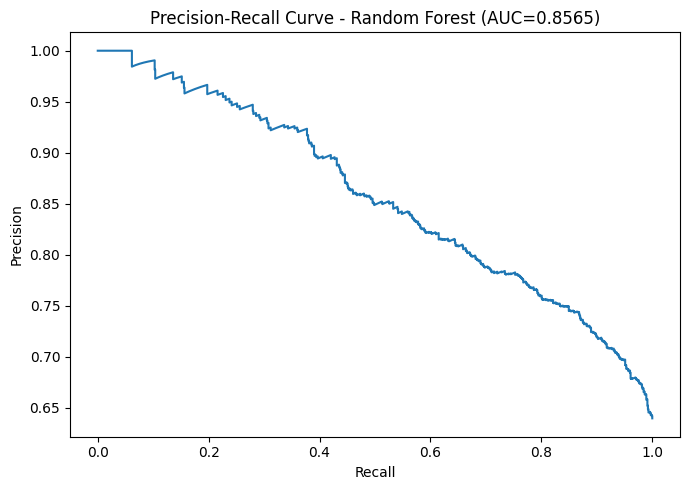

In [63]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob_rf)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - Random Forest (AUC={pr_auc:.4f})")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

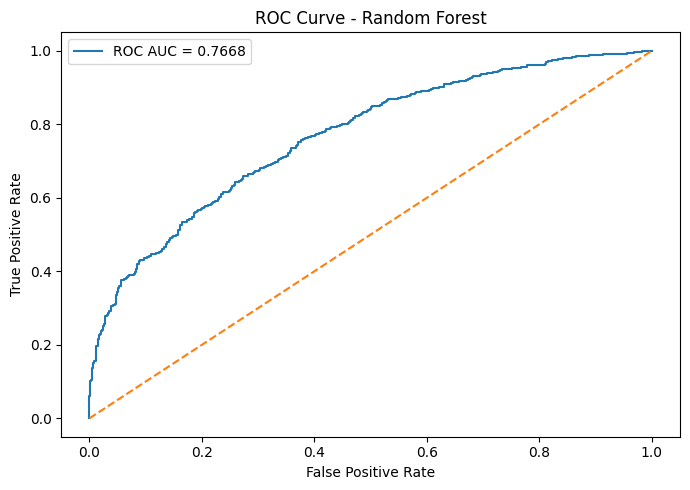

In [64]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_value = auc(fpr, tpr)
plt.figure(figsize=(7,5))
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
threshold_results_df.to_csv("results/threshold_analysis.csv", index=False)
error_analysis_df.to_csv("results/error_analysis.csv", index=False)
slice_priority_rf.to_csv("results/slice_priority_rf.csv", index=False)
slice_priority_hybrid.to_csv("results/slice_priority_hybrid.csv", index=False)
slice_category_rf.to_csv("results/slice_category_rf.csv", index=False)
slice_category_hybrid.to_csv("results/slice_category_hybrid.csv", index=False)

# Define slice_peak_rf and slice_peak_hybrid
slice_peak_rf = slice_performance(error_analysis_df, "actual", "rf_pred_default", "is_peak_season")
silce_peak_hybrid = slice_performance(error_analysis_df, "actual", "hybrid_pred", "is_peak_season")

slice_peak_rf.to_csv("results/slice_peak_rf.csv", index=False)
silce_peak_hybrid.to_csv("results/slice_peak_hybrid.csv", index=False)
priority_business_df.to_csv("results/high_priority_recall_comparison.csv", index=False)
business_eval_df.to_csv("results/business_evaluation_summary.csv", index=False)
full_results_with_tuned_df.to_csv("results/full_results_with_tuned_model.csv", index=False)

print("Saved Step 3 output files successfully.")

Saved Step 3 output files successfully.


In [68]:
best_recall_model = business_eval_df.sort_values(by="recall", ascending=False).iloc[0]
best_f1_model = business_eval_df.sort_values(by="f1_score", ascending=False).iloc[0]
lowest_fnr_model = business_eval_df.sort_values(by="false_negative_rate", ascending=True).iloc[0]

print("Applied Scientist Findings Summary")
print("=" * 60)
print(f"Best recall model: {best_recall_model['model']} (Recall={best_recall_model['recall']:.4f})")
print(f"Best F1 model: {best_f1_model['model']} (F1={best_f1_model['f1_score']:.4f})")
print(f"Lowest false negative rate: {lowest_fnr_model['model']} (FNR={lowest_fnr_model['false_negative_rate']:.4f})")
print("\nInterpretation:")
print("- Recall is especially important when missed delays have high operational cost.")
print("- Threshold tuning can improve business sensitivity even if precision changes.")
print("- Hybrid reasoning can complement predictive modeling by improving actionability.")

Applied Scientist Findings Summary
Best recall model: Gradient Boosting (Recall=0.8475)
Best F1 model: Gradient Boosting (F1=0.7961)
Lowest false negative rate: Gradient Boosting (FNR=0.1525)

Interpretation:
- Recall is especially important when missed delays have high operational cost.
- Threshold tuning can improve business sensitivity even if precision changes.
- Hybrid reasoning can complement predictive modeling by improving actionability.


In [69]:
print("""
Recruiter-Facing Business Summary
---------------------------------
This project goes beyond standard classification by introducing business-aware evaluation.
In addition to accuracy and F1-score, the system analyzes false negatives, threshold tradeoffs,
high-priority shipment recall, feature importance, and operational error slices across product
categories, shipment priorities, and seasonal demand conditions.

This helps position the project as an applied decision-intelligence system rather than a basic ML model.
""")


Recruiter-Facing Business Summary
---------------------------------
This project goes beyond standard classification by introducing business-aware evaluation.
In addition to accuracy and F1-score, the system analyzes false negatives, threshold tradeoffs,
high-priority shipment recall, feature importance, and operational error slices across product
categories, shipment priorities, and seasonal demand conditions.

This helps position the project as an applied decision-intelligence system rather than a basic ML model.



In [71]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

In [72]:
!streamlit run streamlit_app.py &>/content/logs.txt &

In [73]:
import subprocess
import time

# Start tunnel
tunnel = subprocess.Popen(
    ["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Extract URL
import re

output = tunnel.stderr.read().decode()
url = re.findall(r"(https://[-a-z0-9]+\.trycloudflare\.com)", output)

if url:
    print("Streamlit App URL:", url[0])
else:
    print("URL not found. Check logs.")

KeyboardInterrupt: 

In [74]:
!cat /content/logs.txt | tail -n 50

/bin/bash: line 1: streamlit: command not found


In [75]:
!ps aux | grep cloudlared

root        6230  0.0  0.0   7372  3336 ?        S    05:08   0:00 /bin/bash -c ps aux | grep cloudlared
root        6232  0.0  0.0   6480  2416 ?        S    05:08   0:00 grep cloudlared


In [76]:
%%writefile streamlit_app.py
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt

from src.data_generator import generate_supply_chain_data
from src.feature_engineering import add_engineered_features
from src.train_model import (
    split_data,
    build_preprocessor,
    train_random_forest,
    train_logistic_regression,
    train_gradient_boosting
)
from src.agents import InventoryAgent, LogisticsAgent, ManagerAgent
from src.orchestrator import predict_single_shipment


st.set_page_config(
    page_title="Agentic AI Supply Chain Risk Orchestrator",
    layout="wide"
)


@st.cache_data
def load_dataset():
    df = generate_supply_chain_data(n_samples=8000, random_state=42)
    return df


@st.cache_resource
def train_models():
    df = load_dataset()
    X_train, X_test, y_train, y_test = split_data(df)
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)

    rf_model = train_random_forest(X_train, y_train, preprocessor)
    logreg_model = train_logistic_regression(X_train, y_train, preprocessor)
    gb_model = train_gradient_boosting(X_train, y_train, preprocessor)

    return df, X_train, X_test, y_train, y_test, rf_model, logreg_model, gb_model


def build_input_dataframe(user_input):
    df_input = pd.DataFrame([user_input])
    df_input = add_engineered_features(df_input)
    return df_input


def summarize_model_scores():
    return pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Gradient Boosting",
            "ML + Agent Hybrid"
        ],
        "Purpose": [
            "Baseline linear model",
            "Primary tree-based model",
            "Boosted ensemble model",
            "Decision intelligence layer"
        ]
    })


def get_feature_importance_df(rf_model, X_train):
    preprocessor = rf_model.named_steps["preprocessor"]
    estimator = rf_model.named_steps["model"]

    numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

    feature_names = []
    feature_names.extend(numeric_cols)

    encoder = preprocessor.named_transformers_["cat"]
    encoded_cat_names = encoder.get_feature_names_out(categorical_cols).tolist()
    feature_names.extend(encoded_cat_names)

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": estimator.feature_importances_
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    return feature_importance_df


# Load data and models
df, X_train, X_test, y_train, y_test, rf_model, logreg_model, gb_model = train_models()

# App title
st.title("Agentic AI Supply Chain Risk Orchestrator")
st.markdown(
    "Hybrid **ML + multi-agent system** for shipment delay prediction, root-cause diagnosis, and operational recommendations."
)

st.sidebar.header("Shipment Input Parameters")

inventory_level = st.sidebar.slider("Inventory Level", 20, 800, 120)
demand_forecast = st.sidebar.slider("Demand Forecast", 50, 1000, 540)
supplier_reliability = st.sidebar.slider("Supplier Reliability", 0.55, 0.99, 0.66)
supplier_lead_time_days = st.sidebar.slider("Supplier Lead Time (Days)", 1, 20, 15)
warehouse_utilization = st.sidebar.slider("Warehouse Utilization", 0.45, 0.98, 0.91)
shipping_distance = st.sidebar.slider("Shipping Distance (km)", 20, 3500, 2200)
weather_severity = st.sidebar.slider("Weather Severity", 0, 10, 8)
carrier_delay_history = st.sidebar.slider("Carrier Delay History", 0.01, 0.45, 0.31)
carrier_reliability = st.sidebar.slider("Carrier Reliability", 0.55, 0.99, 0.68)
processing_time_hours = st.sidebar.slider("Processing Time (Hours)", 2.0, 96.0, 48.0)
promised_delivery_days = st.sidebar.slider("Promised Delivery Days", 1, 10, 4)
week_of_year = st.sidebar.slider("Week of Year", 1, 52, 48)
warehouse_region = st.sidebar.selectbox("Warehouse Region", ["North", "South", "East", "West"], index=2)
product_category = st.sidebar.selectbox("Product Category", ["Electronics", "Apparel", "Home", "Groceries", "Beauty"], index=0)
shipment_priority = st.sidebar.selectbox("Shipment Priority", ["Low", "Medium", "High"], index=2)

is_peak_season = 1 if week_of_year in [45, 46, 47, 48, 49, 50, 51, 52, 1, 2] else 0
inventory_to_demand_ratio = inventory_level / max(demand_forecast, 1)

user_input = {
    "inventory_level": inventory_level,
    "demand_forecast": demand_forecast,
    "supplier_reliability": supplier_reliability,
    "supplier_lead_time_days": supplier_lead_time_days,
    "warehouse_utilization": warehouse_utilization,
    "shipping_distance": shipping_distance,
    "weather_severity": weather_severity,
    "carrier_delay_history": carrier_delay_history,
    "carrier_reliability": carrier_reliability,
    "processing_time_hours": processing_time_hours,
    "promised_delivery_days": promised_delivery_days,
    "week_of_year": week_of_year,
    "warehouse_region": warehouse_region,
    "product_category": product_category,
    "shipment_priority": shipment_priority,
    "is_peak_season": is_peak_season,
    "inventory_to_demand_ratio": inventory_to_demand_ratio
}

if st.sidebar.button("Analyze Shipment Risk"):
    input_df = build_input_dataframe(user_input)
    result = predict_single_shipment(input_df, rf_model)

    ml_prob = result["ml_delay_probability"]
    inventory_report = result["inventory_report"]
    logistics_report = result["logistics_report"]
    manager_decision = result["manager_decision"]

    st.subheader("Prediction Summary")

    col1, col2, col3 = st.columns(3)
    col1.metric("ML Delay Probability", f"{ml_prob:.2%}")
    col2.metric("Delay Risk", manager_decision["delay_risk"])
    col3.metric("Primary Cause", manager_decision["primary_cause"])

    st.markdown("---")

    st.subheader("Manager Decision")
    st.write(manager_decision["reasoning_summary"])

    st.write("**Recommended Actions**")
    for action in manager_decision["recommended_actions"]:
        st.write(f"- {action}")

    st.markdown("---")

    col_a, col_b = st.columns(2)

    with col_a:
        st.subheader("Inventory Agent")
        st.write(f"**Severity:** {inventory_report['severity']}")
        st.write(f"**Confidence:** {inventory_report['confidence']}")
        st.write("**Findings:**")
        for finding in inventory_report["findings"]:
            st.write(f"- {finding}")
        st.write("**Recommended Actions:**")
        for action in inventory_report["recommended_actions"]:
            st.write(f"- {action}")

    with col_b:
        st.subheader("Logistics Agent")
        st.write(f"**Severity:** {logistics_report['severity']}")
        st.write(f"**Confidence:** {logistics_report['confidence']}")
        st.write("**Findings:**")
        for finding in logistics_report["findings"]:
            st.write(f"- {finding}")
        st.write("**Recommended Actions:**")
        for action in logistics_report["recommended_actions"]:
            st.write(f"- {action}")

st.markdown("---")

st.subheader("Project System Overview")
st.dataframe(summarize_model_scores(), use_container_width=True)

st.markdown("---")

st.subheader("Input Dataset Preview")
st.dataframe(df.head(10), use_container_width=True)

st.markdown("---")

st.subheader("Top Feature Importances")
feature_importance_df = get_feature_importance_df(rf_model, X_train).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df["feature"][::-1], feature_importance_df["importance"][::-1])
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
st.pyplot(fig)

st.markdown("---")

st.subheader("Why This Project Matters")
st.write(
    """
    This demo illustrates how a hybrid ML + Agentic AI system can move beyond prediction
    into decision intelligence by combining:
    - predictive risk modeling
    - specialized agent reasoning
    - root-cause analysis
    - actionable recommendations
    """
)

Writing streamlit_app.py


In [77]:
import os

print("Files in current directory:")
print(os.listdir())

print("\nFiles inside src/:")
print(os.listdir("src"))

Files in current directory:
['.config', 'src', 'logs.txt', 'data', 'results', 'streamlit_app.py', 'cloudflared-linux-amd64', 'sample_data']

Files inside src/:
['agents.py', 'train_model.py', 'data_generator.py', '__pycache__', 'orchestrator.py', 'feature_engineering.py']


In [78]:
!streamlit run streamlit_app.py &>/content/logs.txt &

In [79]:
!cat /content/logs.txt | tail -n 50

/bin/bash: line 1: streamlit: command not found


In [80]:
architecture_text = """
Input Shipment Data
        |
        v
Feature Engineering
        |
        v
Random Forest Delay Predictor
        |
        v
+-----------------------------+
|   Inventory Agent           |
|   Logistics Agent           |
+-----------------------------+
        |
        v
Manager Agent
        |
        v
Final Delay Risk + Root Cause + Recommended Actions
"""

print(architecture_text)


Input Shipment Data
        |
        v
Feature Engineering
        |
        v
Random Forest Delay Predictor
        |
        v
+-----------------------------+
|   Inventory Agent           |
|   Logistics Agent           |
+-----------------------------+
        |
        v
Manager Agent
        |
        v
Final Delay Risk + Root Cause + Recommended Actions



In [81]:
print("""
Demo Summary
------------
Built an interactive Streamlit application for a hybrid ML + Agentic AI supply chain risk system.
The app allows users to simulate shipment scenarios, estimate delay probability, inspect Inventory
and Logistics agent findings, identify primary risk drivers, and generate operational recommendations.

This improves the project’s recruiter and interviewer impact by making the system visible,
explainable, and easy to demonstrate.
""")


Demo Summary
------------
Built an interactive Streamlit application for a hybrid ML + Agentic AI supply chain risk system.
The app allows users to simulate shipment scenarios, estimate delay probability, inspect Inventory
and Logistics agent findings, identify primary risk drivers, and generate operational recommendations.

This improves the project’s recruiter and interviewer impact by making the system visible,
explainable, and easy to demonstrate.



In [82]:
print("Step 4 Completed Successfully")
print("=" * 60)
print("My project now includes:")
print("- Interactive Streamlit demo")
print("- Shipment input form")
print("- ML risk prediction")
print("- Inventory agent analysis")
print("- Logistics agent analysis")
print("- Manager decision summary")
print("- Recommended actions")
print("- Feature importance visualization")
print("- Recruiter-friendly live demo")

Step 4 Completed Successfully
My project now includes:
- Interactive Streamlit demo
- Shipment input form
- ML risk prediction
- Inventory agent analysis
- Logistics agent analysis
- Manager decision summary
- Recommended actions
- Feature importance visualization
- Recruiter-friendly live demo
